<a href="https://colab.research.google.com/github/zyf-hitsz/PytorchLearning/blob/main/%E7%A5%9E%E7%BB%8F%E7%BD%91%E7%BB%9C/%E5%8D%B7%E7%A7%AF%E7%A5%9E%E7%BB%8F%E7%BD%91%E7%BB%9C/ResNetipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##残差网络ResNet
随着我们设计越来越深的网络，深刻理解“新添加的层如何提升神经网络的性能”变得至关重要。更重要的是设计网络的能力，在这种网络中，添加层会使网络更具表现力，
为了取得质的突破，我们需要一些数学基础知识。

## 函数类

首先，假设有一类特定的神经网络架构$\mathcal{F}$，它包括学习速率和其他超参数设置。
对于所有$f \in \mathcal{F}$，存在一些参数集（例如权重和偏置），这些参数可以通过在合适的数据集上进行训练而获得。
现在假设$f^*$是我们真正想要找到的函数，如果是$f^* \in \mathcal{F}$，那我们可以轻而易举的训练得到它，但通常我们不会那么幸运。
相反，我们将尝试找到一个函数$f^*_\mathcal{F}$，这是我们在$\mathcal{F}$中的最佳选择。
例如，给定一个具有$\mathbf{X}$特性和$\mathbf{y}$标签的数据集，我们可以尝试通过解决以下优化问题来找到它：

$$f^*_\mathcal{F} := \mathop{\mathrm{argmin}}_f L(\mathbf{X}, \mathbf{y}, f) \text{ subject to } f \in \mathcal{F}.$$

那么，怎样得到更近似真正$f^*$的函数呢？
唯一合理的可能性是，我们需要设计一个更强大的架构$\mathcal{F}'$。
换句话说，我们预计$f^*_{\mathcal{F}'}$比$f^*_{\mathcal{F}}$“更近似”。
然而，如果$\mathcal{F} \not\subseteq \mathcal{F}'$，则无法保证新的体系“更近似”。
事实上，$f^*_{\mathcal{F}'}$可能更糟：
如下图所示，对于非嵌套函数（non-nested function）类，较复杂的函数类并不总是向“真”函数$f^*$靠拢（复杂度由$\mathcal{F}_1$向$\mathcal{F}_6$递增）。
在下图的左边，虽然$\mathcal{F}_3$比$\mathcal{F}_1$更接近$f^*$，但$\mathcal{F}_6$却离的更远了。
相反对于下图右侧的嵌套函数（nested function）类$\mathcal{F}_1 \subseteq \ldots \subseteq \mathcal{F}_6$，我们可以避免上述问题。

![对于非嵌套函数类，较复杂（由较大区域表示）的函数类不能保证更接近“真”函数（ $f^*$ ）。这种现象在嵌套函数类中不会发生。](http://d2l.ai/_images/functionclasses.svg)


因此，只有当较复杂的函数类包含较小的函数类时，我们才能确保提高它们的性能。
对于深度神经网络，如果我们能将新添加的层训练成*恒等映射*（identity function）$f(\mathbf{x}) = \mathbf{x}$，新模型和原模型将同样有效。
同时，由于新模型可能得出更优的解来拟合训练数据集，因此添加层似乎更容易降低训练误差。
残差网络ResNet的提出正是针对这一问题，其核心思想是：每个附加层都应该更容易地包含原始函数作为其元素之一。 于是，残差块（residual blocks）便诞生了，这个设计对如何建立深层神经网络产生了深远的影响。

###残差块
让我们聚焦于神经网络局部：如图所示，假设我们的原始输入为$x$，而希望学出的理想映射为$f(\mathbf{x})$（作为图中上方激活函数的输入）。
左图虚线框中的部分需要直接拟合出该映射$f(\mathbf{x})$，而右图虚线框中的部分则需要拟合出残差映射$f(\mathbf{x}) - \mathbf{x}$。
残差映射在现实中往往更容易优化。
以本节开头提到的恒等映射作为我们希望学出的理想映射$f(\mathbf{x})$，我们只需将 右图虚线框内上方的加权运算（如仿射）的权重和偏置参数设成0，那么$f(\mathbf{x})$即为恒等映射。
实际中，当理想映射$f(\mathbf{x})$极接近于恒等映射时，残差映射也易于捕捉恒等映射的细微波动。
右图是ResNet的基础架构--*残差块*（residual block）。
在残差块中，输入可通过跨层数据线路更快地向前传播。

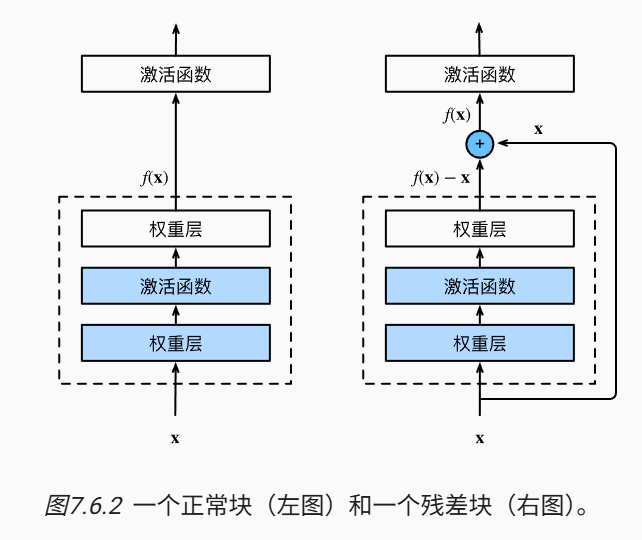

ResNet沿用了VGG完整的$3\times 3$卷积层设计。
残差块里首先有2个有相同输出通道数的$3\times 3$卷积层。
每个卷积层后接一个批量规范化层和ReLU激活函数。
然后我们通过跨层数据通路，跳过这2个卷积运算，将输入直接加在最后的ReLU激活函数前。
这样的设计要求2个卷积层的输出与输入形状一样，从而使它们可以相加。
如果想改变通道数，就需要引入一个额外的$1\times 1$卷积层来将输入变换成需要的形状后再做相加运算。

残差块的实现如下：


In [10]:
import torch
from torch import nn
from torch.nn import functional as F



class Residual(nn.Module):
    def __init__(self, input_channels, num_channels,
                 use_1x1conv=False, strides=1):
        super().__init__()
        self.conv1 = nn.Conv2d(input_channels, num_channels,
                               kernel_size=3, padding=1, stride=strides)
        self.conv2 = nn.Conv2d(num_channels, num_channels,
                               kernel_size=3, padding=1)
        if use_1x1conv:
            self.conv3 = nn.Conv2d(input_channels, num_channels,
                                   kernel_size=1, stride=strides)
        else:
            self.conv3 = None
        self.bn1 = nn.BatchNorm2d(num_channels)
        self.bn2 = nn.BatchNorm2d(num_channels)

    def forward(self, X):
        Y = F.relu(self.bn1(self.conv1(X)))
        Y = self.bn2(self.conv2(Y))
        if self.conv3:
            X = self.conv3(X)
        Y += X
        return F.relu(Y)

如图所示，此代码生成两种类型的网络：
一种是当`use_1x1conv=False`时，应用ReLU非线性函数之前，将输入添加到输出。
另一种是当`use_1x1conv=True`时，添加通过$1 \times 1$卷积调整通道和分辨率。

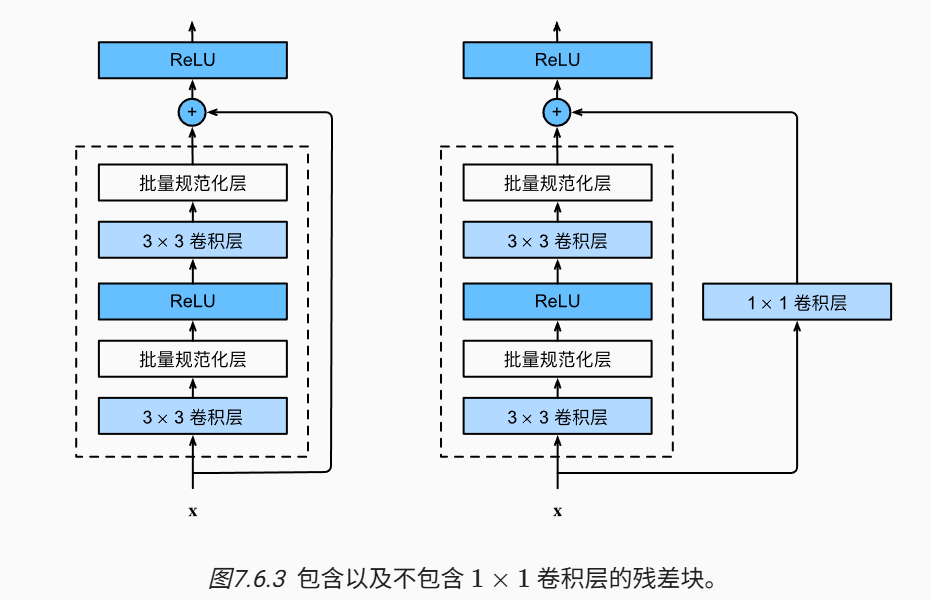

下面我们来查看**输入和输出形状一致**的情况。


In [11]:
blk = Residual(3,3)
X = torch.rand(4, 3, 6, 6)
Y = blk(X)
Y.shape

torch.Size([4, 3, 6, 6])

我们也可以在**增加输出通道数的同时，减半输出的高和宽**。

In [12]:
blk = Residual(3,6, use_1x1conv=True, strides=2)
blk(X).shape

torch.Size([4, 6, 3, 3])

### ResNet模型

ResNet的前两层跟之前介绍的GoogLeNet中的一样：
在输出通道数为64、步幅为2的$7 \times 7$卷积层后，接步幅为2的$3 \times 3$的最大汇聚层。
不同之处在于ResNet每个卷积层后增加了批量规范化层。

In [13]:
b1 = nn.Sequential(nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3),
                   nn.BatchNorm2d(64), nn.ReLU(),
                   nn.MaxPool2d(kernel_size=3, stride=2, padding=1))

GoogLeNet在后面接了4个由Inception块组成的模块。
ResNet则使用4个由残差块组成的模块，每个模块使用若干个同样输出通道数的残差块。
第一个模块的通道数同输入通道数一致。
由于之前已经使用了步幅为2的最大汇聚层，所以无须减小高和宽。
之后的每个模块在第一个残差块里将上一个模块的通道数翻倍，并将高和宽减半。

下面我们来实现这个模块。注意，我们对第一个模块做了特别处理。


In [14]:
def resnet_block(input_channels, num_channels, num_residuals,
                 first_block=False):
    blk = []
    for i in range(num_residuals):
        if i == 0 and not first_block:
            blk.append(Residual(input_channels, num_channels,
                                use_1x1conv=True, strides=2))
        else:
            blk.append(Residual(num_channels, num_channels))
    return blk

接着在ResNet加入所有残差块，这里每个模块使用2个残差块。


In [15]:
b2 = nn.Sequential(*resnet_block(64, 64, 2, first_block=True))
b3 = nn.Sequential(*resnet_block(64, 128, 2))
b4 = nn.Sequential(*resnet_block(128, 256, 2))
b5 = nn.Sequential(*resnet_block(256, 512, 2))

最后，在ResNet中加入全局平均汇聚层，以及全连接层输出。

In [16]:
net = nn.Sequential(b1, b2, b3, b4, b5,
                    nn.AdaptiveAvgPool2d((1,1)),
                    nn.Flatten(), nn.Linear(512, 10))

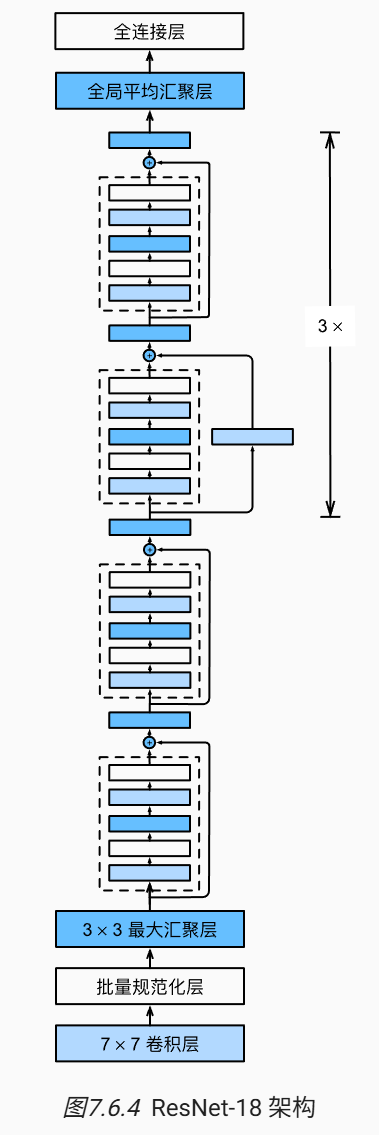

在训练ResNet之前，让我们观察一下ResNet中不同模块的输入形状是如何变化的。
在之前所有架构中，分辨率降低，通道数量增加，直到全局平均汇聚层聚集所有特征。

In [17]:
X = torch.rand(size=(1, 1, 224, 224))
for layer in net:
    X = layer(X)
    print(layer.__class__.__name__,'output shape:\t', X.shape)

Sequential output shape:	 torch.Size([1, 64, 56, 56])
Sequential output shape:	 torch.Size([1, 64, 56, 56])
Sequential output shape:	 torch.Size([1, 128, 28, 28])
Sequential output shape:	 torch.Size([1, 256, 14, 14])
Sequential output shape:	 torch.Size([1, 512, 7, 7])
AdaptiveAvgPool2d output shape:	 torch.Size([1, 512, 1, 1])
Flatten output shape:	 torch.Size([1, 512])
Linear output shape:	 torch.Size([1, 10])


###训练模型
和之前一样，在在Fashion-MNIST数据集上训练ResNet。下面是完整代码和训练结果。

Training device: cuda


100%|██████████| 26.4M/26.4M [00:01<00:00, 13.8MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 204kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.79MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 16.6MB/s]


Epoch [01/10]  train loss: 0.5018  train acc: 0.8274  test loss: 0.4122  test acc: 0.8457
Epoch [02/10]  train loss: 0.2548  train acc: 0.9058  test loss: 0.5883  test acc: 0.7979
Epoch [03/10]  train loss: 0.1944  train acc: 0.9290  test loss: 0.2837  test acc: 0.8997
Epoch [04/10]  train loss: 0.1475  train acc: 0.9469  test loss: 0.3736  test acc: 0.8679
Epoch [05/10]  train loss: 0.1115  train acc: 0.9601  test loss: 0.2821  test acc: 0.9051
Epoch [06/10]  train loss: 0.0825  train acc: 0.9710  test loss: 0.4104  test acc: 0.8730
Epoch [07/10]  train loss: 0.0574  train acc: 0.9801  test loss: 0.3814  test acc: 0.8962
Epoch [08/10]  train loss: 0.0407  train acc: 0.9872  test loss: 0.3046  test acc: 0.9113
Epoch [09/10]  train loss: 0.0211  train acc: 0.9939  test loss: 0.3426  test acc: 0.9111
Epoch [10/10]  train loss: 0.0115  train acc: 0.9973  test loss: 0.7321  test acc: 0.8416


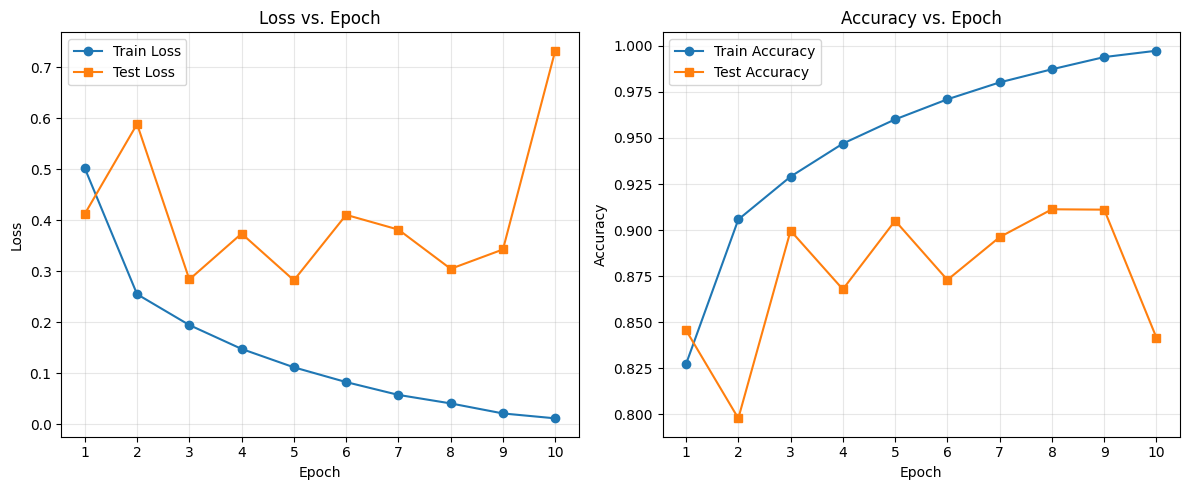

In [18]:
import torch
from torch import nn
from torch.nn import functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt


# =========================
# 1. 残差模块
# =========================
class Residual(nn.Module):
    def __init__(
        self,
        input_channels,
        num_channels,
        use_1x1conv=False,
        strides=1
    ):
        super().__init__()

        self.conv1 = nn.Conv2d(
            input_channels,
            num_channels,
            kernel_size=3,
            padding=1,
            stride=strides
        )
        self.conv2 = nn.Conv2d(
            num_channels,
            num_channels,
            kernel_size=3,
            padding=1
        )

        if use_1x1conv:
            self.conv3 = nn.Conv2d(
                input_channels,
                num_channels,
                kernel_size=1,
                stride=strides
            )
        else:
            self.conv3 = None

        self.bn1 = nn.BatchNorm2d(num_channels)
        self.bn2 = nn.BatchNorm2d(num_channels)

    def forward(self, x):
        y = F.relu(self.bn1(self.conv1(x)))
        y = self.bn2(self.conv2(y))

        if self.conv3 is not None:
            x = self.conv3(x)

        y = y + x
        return F.relu(y)


# =========================
# 2. 构建 ResNet-18
# =========================
def resnet_block(
    input_channels,
    num_channels,
    num_residuals,
    first_block=False
):
    block = []

    for i in range(num_residuals):
        if i == 0 and not first_block:
            block.append(
                Residual(
                    input_channels,
                    num_channels,
                    use_1x1conv=True,
                    strides=2
                )
            )
        else:
            block.append(
                Residual(num_channels, num_channels)
            )

    return block


def build_resnet18():
    b1 = nn.Sequential(
        nn.Conv2d(
            1, 64,
            kernel_size=7,
            stride=2,
            padding=3
        ),
        nn.BatchNorm2d(64),
        nn.ReLU(),
        nn.MaxPool2d(
            kernel_size=3,
            stride=2,
            padding=1
        )
    )

    b2 = nn.Sequential(
        *resnet_block(64, 64, 2, first_block=True)
    )
    b3 = nn.Sequential(
        *resnet_block(64, 128, 2)
    )
    b4 = nn.Sequential(
        *resnet_block(128, 256, 2)
    )
    b5 = nn.Sequential(
        *resnet_block(256, 512, 2)
    )

    return nn.Sequential(
        b1,
        b2,
        b3,
        b4,
        b5,
        nn.AdaptiveAvgPool2d((1, 1)),
        nn.Flatten(),
        nn.Linear(512, 10)
    )


# 对应 d2l.train_ch6 中的参数初始化方式
def init_weights(module):
    if isinstance(module, (nn.Conv2d, nn.Linear)):
        nn.init.xavier_uniform_(module.weight)


# =========================
# 3. Fashion-MNIST 数据集
# =========================
def load_fashion_mnist(batch_size):
    transform = transforms.Compose([
        transforms.Resize((96, 96)),
        transforms.ToTensor()
    ])

    train_dataset = datasets.FashionMNIST(
        root="./data",
        train=True,
        transform=transform,
        download=True
    )

    test_dataset = datasets.FashionMNIST(
        root="./data",
        train=False,
        transform=transform,
        download=True
    )

    # Windows 环境下使用 num_workers=0 更稳定
    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=0,
        pin_memory=torch.cuda.is_available()
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0,
        pin_memory=torch.cuda.is_available()
    )

    return train_loader, test_loader


# =========================
# 4. 模型评估
# =========================
def evaluate(model, data_loader, loss_fn, device):
    model.eval()

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    with torch.no_grad():
        for features, labels in data_loader:
            features = features.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model(features)
            loss = loss_fn(outputs, labels)

            batch_size = labels.size(0)
            total_loss += loss.item() * batch_size
            total_correct += (
                outputs.argmax(dim=1) == labels
            ).sum().item()
            total_samples += batch_size

    average_loss = total_loss / total_samples
    accuracy = total_correct / total_samples

    return average_loss, accuracy


# =========================
# 5. 训练函数
# =========================
def train(
    model,
    train_loader,
    test_loader,
    num_epochs,
    learning_rate,
    device
):
    model.apply(init_weights)
    model.to(device)

    loss_fn = nn.CrossEntropyLoss()
    optimizer = torch.optim.SGD(
        model.parameters(),
        lr=learning_rate
    )

    history = {
        "train_loss": [],
        "test_loss": [],
        "train_acc": [],
        "test_acc": []
    }

    for epoch in range(num_epochs):
        model.train()

        total_loss = 0.0
        total_correct = 0
        total_samples = 0

        for features, labels in train_loader:
            features = features.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            optimizer.zero_grad()

            outputs = model(features)
            loss = loss_fn(outputs, labels)

            loss.backward()
            optimizer.step()

            batch_size = labels.size(0)
            total_loss += loss.item() * batch_size
            total_correct += (
                outputs.argmax(dim=1) == labels
            ).sum().item()
            total_samples += batch_size

        train_loss = total_loss / total_samples
        train_acc = total_correct / total_samples

        test_loss, test_acc = evaluate(
            model,
            test_loader,
            loss_fn,
            device
        )

        history["train_loss"].append(train_loss)
        history["test_loss"].append(test_loss)
        history["train_acc"].append(train_acc)
        history["test_acc"].append(test_acc)

        print(
            f"Epoch [{epoch + 1:02d}/{num_epochs}]  "
            f"train loss: {train_loss:.4f}  "
            f"train acc: {train_acc:.4f}  "
            f"test loss: {test_loss:.4f}  "
            f"test acc: {test_acc:.4f}"
        )

    return history


# =========================
# 6. 绘制训练曲线
# =========================
def plot_history(history):
    epochs = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(12, 5))

    # Loss 曲线
    plt.subplot(1, 2, 1)
    plt.plot(
        epochs,
        history["train_loss"],
        marker="o",
        label="Train Loss"
    )
    plt.plot(
        epochs,
        history["test_loss"],
        marker="s",
        label="Test Loss"
    )
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Loss vs. Epoch")
    plt.xticks(epochs)
    plt.grid(alpha=0.3)
    plt.legend()

    # Accuracy 曲线
    plt.subplot(1, 2, 2)
    plt.plot(
        epochs,
        history["train_acc"],
        marker="o",
        label="Train Accuracy"
    )
    plt.plot(
        epochs,
        history["test_acc"],
        marker="s",
        label="Test Accuracy"
    )
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Accuracy vs. Epoch")
    plt.xticks(epochs)
    plt.grid(alpha=0.3)
    plt.legend()

    plt.tight_layout()
    plt.savefig("resnet18_training_curves.png", dpi=300)
    plt.show()


# =========================
# 7. 主程序
# =========================
def main():
    # 保持原代码超参数不变
    learning_rate = 0.05
    num_epochs = 10
    batch_size = 256

    device = torch.device(
        "cuda" if torch.cuda.is_available() else "cpu"
    )
    print(f"Training device: {device}")

    train_loader, test_loader = load_fashion_mnist(
        batch_size=batch_size
    )

    model = build_resnet18()

    history = train(
        model=model,
        train_loader=train_loader,
        test_loader=test_loader,
        num_epochs=num_epochs,
        learning_rate=learning_rate,
        device=device
    )

    plot_history(history)

    # 保存最终模型参数
    torch.save(
        model.state_dict(),
        "resnet18_fashion_mnist.pth"
    )


if __name__ == "__main__":
    main()

可以看到随着轮数增加，训练集被很好地拟合，测试集不稳定，在后期明显出现了过拟合。ResNet-18 对 Fashion-MNIST 来说模型容量偏大，加上我们没有数据增强、权重衰减等正则化措施，也没有BatchNorm、学习率衰减等措施，导致出现明显过拟合。

这一版本我们加入学习率衰减、权重衰减和标准化，别的不变。

Training device: cuda
Epoch [01/10]  lr: 0.050000  train loss: 0.4966  train acc: 0.8299  test loss: 0.3839  test acc: 0.8547
Epoch [02/10]  lr: 0.050000  train loss: 0.2570  train acc: 0.9061  test loss: 0.4556  test acc: 0.8258
Epoch [03/10]  lr: 0.050000  train loss: 0.1949  train acc: 0.9282  test loss: 0.4797  test acc: 0.8223
Epoch [04/10]  lr: 0.050000  train loss: 0.1531  train acc: 0.9440  test loss: 0.4368  test acc: 0.8489
Epoch [05/10]  lr: 0.050000  train loss: 0.1192  train acc: 0.9578  test loss: 0.5169  test acc: 0.8411
Epoch [06/10]  lr: 0.005000  train loss: 0.0588  train acc: 0.9826  test loss: 0.2335  test acc: 0.9208
Epoch [07/10]  lr: 0.005000  train loss: 0.0385  train acc: 0.9914  test loss: 0.2273  test acc: 0.9256
Epoch [08/10]  lr: 0.005000  train loss: 0.0304  train acc: 0.9945  test loss: 0.2299  test acc: 0.9259
Epoch [09/10]  lr: 0.000500  train loss: 0.0247  train acc: 0.9966  test loss: 0.2295  test acc: 0.9266
Epoch [10/10]  lr: 0.000500  train loss: 0

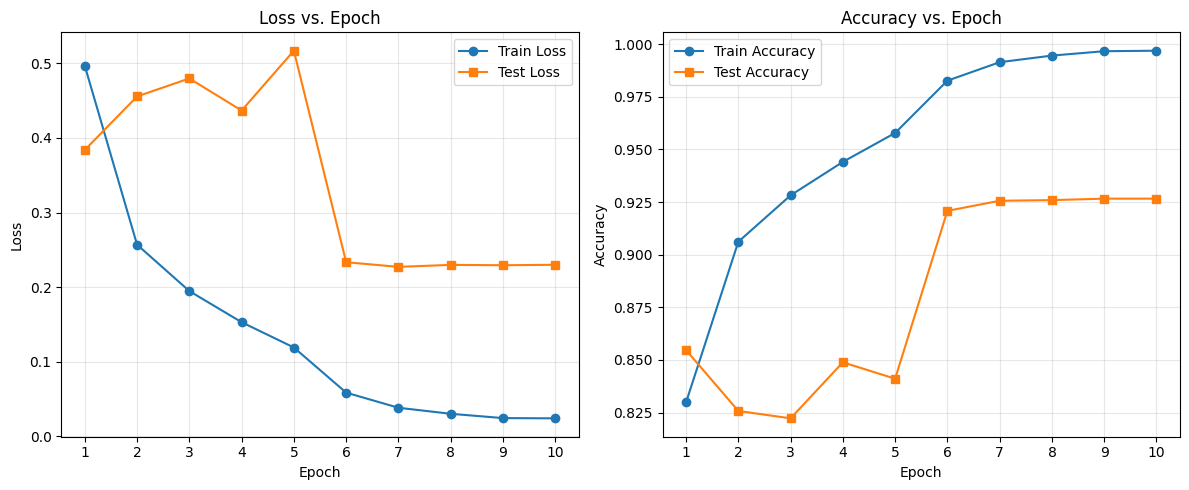

In [19]:
import torch
from torch import nn
from torch.nn import functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt


# =========================
# 1. 残差模块
# =========================
class Residual(nn.Module):
    def __init__(
        self,
        input_channels,
        num_channels,
        use_1x1conv=False,
        strides=1
    ):
        super().__init__()

        self.conv1 = nn.Conv2d(
            input_channels,
            num_channels,
            kernel_size=3,
            padding=1,
            stride=strides
        )

        self.conv2 = nn.Conv2d(
            num_channels,
            num_channels,
            kernel_size=3,
            padding=1
        )

        if use_1x1conv:
            self.conv3 = nn.Conv2d(
                input_channels,
                num_channels,
                kernel_size=1,
                stride=strides
            )
        else:
            self.conv3 = None

        self.bn1 = nn.BatchNorm2d(num_channels)
        self.bn2 = nn.BatchNorm2d(num_channels)

    def forward(self, x):
        y = F.relu(self.bn1(self.conv1(x)))
        y = self.bn2(self.conv2(y))

        if self.conv3 is not None:
            x = self.conv3(x)

        y = y + x
        return F.relu(y)


# =========================
# 2. 构建 ResNet-18
# =========================
def resnet_block(
    input_channels,
    num_channels,
    num_residuals,
    first_block=False
):
    block = []

    for i in range(num_residuals):
        if i == 0 and not first_block:
            block.append(
                Residual(
                    input_channels,
                    num_channels,
                    use_1x1conv=True,
                    strides=2
                )
            )
        else:
            block.append(
                Residual(
                    num_channels,
                    num_channels
                )
            )

    return block


def build_resnet18():
    b1 = nn.Sequential(
        nn.Conv2d(
            1,
            64,
            kernel_size=7,
            stride=2,
            padding=3
        ),
        nn.BatchNorm2d(64),
        nn.ReLU(),
        nn.MaxPool2d(
            kernel_size=3,
            stride=2,
            padding=1
        )
    )

    b2 = nn.Sequential(
        *resnet_block(
            64,
            64,
            2,
            first_block=True
        )
    )

    b3 = nn.Sequential(
        *resnet_block(64, 128, 2)
    )

    b4 = nn.Sequential(
        *resnet_block(128, 256, 2)
    )

    b5 = nn.Sequential(
        *resnet_block(256, 512, 2)
    )

    return nn.Sequential(
        b1,
        b2,
        b3,
        b4,
        b5,
        nn.AdaptiveAvgPool2d((1, 1)),
        nn.Flatten(),
        nn.Linear(512, 10)
    )


# 对应 d2l.train_ch6 中的参数初始化
def init_weights(module):
    if isinstance(module, (nn.Conv2d, nn.Linear)):
        nn.init.xavier_uniform_(module.weight)


# =========================
# 3. 加载 Fashion-MNIST
# =========================
def load_fashion_mnist(batch_size):
    transform = transforms.Compose([
        transforms.Resize((96, 96)),
        transforms.ToTensor(),

        # 新增：Fashion-MNIST 标准化
        transforms.Normalize(
            mean=(0.2860,),
            std=(0.3530,)
        )
    ])

    train_dataset = datasets.FashionMNIST(
        root="./data",
        train=True,
        transform=transform,
        download=True
    )

    test_dataset = datasets.FashionMNIST(
        root="./data",
        train=False,
        transform=transform,
        download=True
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=0,
        pin_memory=torch.cuda.is_available()
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0,
        pin_memory=torch.cuda.is_available()
    )

    return train_loader, test_loader


# =========================
# 4. 测试模型
# =========================
def evaluate(model, data_loader, loss_fn, device):
    model.eval()

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    with torch.no_grad():
        for features, labels in data_loader:
            features = features.to(
                device,
                non_blocking=True
            )
            labels = labels.to(
                device,
                non_blocking=True
            )

            outputs = model(features)
            loss = loss_fn(outputs, labels)

            batch_size = labels.size(0)

            total_loss += loss.item() * batch_size
            total_correct += (
                outputs.argmax(dim=1) == labels
            ).sum().item()
            total_samples += batch_size

    average_loss = total_loss / total_samples
    accuracy = total_correct / total_samples

    return average_loss, accuracy


# =========================
# 5. 训练模型
# =========================
def train(
    model,
    train_loader,
    test_loader,
    num_epochs,
    learning_rate,
    device
):
    model.apply(init_weights)
    model.to(device)

    loss_fn = nn.CrossEntropyLoss()

    # 新增：L2 权重衰减
    # 不增加模型参数，不改变网络结构
    optimizer = torch.optim.SGD(
        model.parameters(),
        lr=learning_rate,
        weight_decay=5e-4
    )

    # 新增：学习率衰减
    # 第5轮结束：0.05 -> 0.005
    # 第8轮结束：0.005 -> 0.0005
    scheduler = torch.optim.lr_scheduler.MultiStepLR(
        optimizer,
        milestones=[5, 8],
        gamma=0.1
    )

    history = {
        "train_loss": [],
        "test_loss": [],
        "train_acc": [],
        "test_acc": [],
        "learning_rate": []
    }

    for epoch in range(num_epochs):
        model.train()

        # 记录当前轮使用的学习率
        current_lr = optimizer.param_groups[0]["lr"]

        total_loss = 0.0
        total_correct = 0
        total_samples = 0

        for features, labels in train_loader:
            features = features.to(
                device,
                non_blocking=True
            )
            labels = labels.to(
                device,
                non_blocking=True
            )

            optimizer.zero_grad()

            outputs = model(features)
            loss = loss_fn(outputs, labels)

            loss.backward()
            optimizer.step()

            batch_size = labels.size(0)

            total_loss += loss.item() * batch_size
            total_correct += (
                outputs.argmax(dim=1) == labels
            ).sum().item()
            total_samples += batch_size

        train_loss = total_loss / total_samples
        train_acc = total_correct / total_samples

        test_loss, test_acc = evaluate(
            model,
            test_loader,
            loss_fn,
            device
        )

        history["train_loss"].append(train_loss)
        history["test_loss"].append(test_loss)
        history["train_acc"].append(train_acc)
        history["test_acc"].append(test_acc)
        history["learning_rate"].append(current_lr)

        print(
            f"Epoch [{epoch + 1:02d}/{num_epochs}]  "
            f"lr: {current_lr:.6f}  "
            f"train loss: {train_loss:.4f}  "
            f"train acc: {train_acc:.4f}  "
            f"test loss: {test_loss:.4f}  "
            f"test acc: {test_acc:.4f}"
        )

        # 在本轮训练完成后更新学习率
        scheduler.step()

    return history


# =========================
# 6. 绘制训练曲线
# =========================
def plot_history(history):
    epochs = range(
        1,
        len(history["train_loss"]) + 1
    )

    plt.figure(figsize=(12, 5))

    # Loss 曲线
    plt.subplot(1, 2, 1)

    plt.plot(
        epochs,
        history["train_loss"],
        marker="o",
        label="Train Loss"
    )

    plt.plot(
        epochs,
        history["test_loss"],
        marker="s",
        label="Test Loss"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Loss vs. Epoch")
    plt.xticks(epochs)
    plt.grid(alpha=0.3)
    plt.legend()

    # Accuracy 曲线
    plt.subplot(1, 2, 2)

    plt.plot(
        epochs,
        history["train_acc"],
        marker="o",
        label="Train Accuracy"
    )

    plt.plot(
        epochs,
        history["test_acc"],
        marker="s",
        label="Test Accuracy"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Accuracy vs. Epoch")
    plt.xticks(epochs)
    plt.grid(alpha=0.3)
    plt.legend()

    plt.tight_layout()
    plt.savefig(
        "resnet18_training_curves_decay.png",
        dpi=300
    )
    plt.show()


# =========================
# 7. 主程序
# =========================
def main():
    # 原有超参数保持不变
    learning_rate = 0.05
    num_epochs = 10
    batch_size = 256

    device = torch.device(
        "cuda" if torch.cuda.is_available()
        else "cpu"
    )

    print(f"Training device: {device}")

    train_loader, test_loader = load_fashion_mnist(
        batch_size=batch_size
    )

    model = build_resnet18()

    history = train(
        model=model,
        train_loader=train_loader,
        test_loader=test_loader,
        num_epochs=num_epochs,
        learning_rate=learning_rate,
        device=device
    )

    plot_history(history)

    torch.save(
        model.state_dict(),
        "resnet18_fashion_mnist_decay.pth"
    )


if __name__ == "__main__":
    main()

改进后的网络不管是在减少过拟合、拟合训练集、测试准确率、稳定性等方面都有提升，但是不难发现过拟合依然是存在的，后续可以通过尝试加入dropout、数据增强、修改模型参数等操作进一步提升效果。

ResNet的特点总结：

| 方面 | 优点 | 缺点 |
|---|---|---|
| 参数与结构 | 残差连接几乎不增加参数；可以稳定地扩展网络深度 | 卷积层较多，整体参数量和显存占用仍明显高于普通浅层 CNN |
| 梯度传播 | 跳跃连接为梯度提供直接通道，缓解梯度消失和网络退化 | 网络过深时仍可能训练困难，不能完全解决梯度、过拟合等问题 |
| 训练速度 | 相同深度下通常比没有残差连接的网络更容易收敛 | 多层卷积计算量大；在 CPU 上训练较慢 |
| 训练稳定性 | BatchNorm 和残差结构使训练更加稳定，可以使用相对较大的学习率 | BatchNorm 对 batch size 较敏感，小批量训练时统计量可能不稳定 |
| 分类效果 | 图像分类表现强，能学习从边缘、纹理到高级语义的多层特征 | 对 Fashion-MNIST 这种简单数据集可能结构过重，性能提升未必与计算成本成正比 |
| 泛化能力 | 残差结构本身泛化能力较好，也容易进行迁移学习 | 参数较多时，小数据集上仍可能过拟合 |
| 调参难度 | 相比同深度的普通 CNN，通常更容易得到较好的结果 | 仍需合理设置学习率、权重衰减、数据增强和学习率衰减策略 |